In [26]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

# Single IV fit

In [27]:
data = np.load("single_iv/eva.npz")
V_mV = data["V_mV"]
I_nA = data["I_nA"]
Tbath_K = data["Tbath_K"]
GN_G0 = 0.18949935853204078
T_K = 0.21497232546013467
Delta_meV = 0.19479995314857806
gamma_meV = 0.0011282098342488703
sigmaV_mV = 0.010314565303472743

settings = {
    "GN_G0": (GN_G0, 0.1, 0.3, False),
    "T_K": (T_K, 0.0, 1.2, False),
    "Delta_meV": (Delta_meV, 0.180, 0.210, False),
    "gamma_meV": (gamma_meV, 1e-9, 25e-3, False),
    "sigmaV_mV": (sigmaV_mV, 0.0, 1.0, False),
    "A_mV": (0.0, 0.0, 4.0, True),
    "nu_GHz": (0.0, 1.0, 20.0, True),
}

# fit only the noise-capable model
from bcs_fit import fit_bcs_conv_noise
from compare_bcs_fits import plot_bcs_conv_noise_fit, print_bcs_comparison_table

fit_row, noise_solution = fit_bcs_conv_noise(
    V_mV,
    I_nA,
    settings,
    maxfev=20_000,
)

print_bcs_comparison_table(
    [fit_row],
    columns=(
        "model",
        "ok",
        "rmse_nA",
        "GN_G0",
        "T_K",
        "Delta_meV",
        "gamma_meV",
        "sigmaV_mV",
    ),
)

Ifit_nA = noise_solution["I_fit_nA"]
fit_values = {parameter.name: parameter.value for parameter in noise_solution["params"]}
fit_errors = {parameter.name: parameter.error for parameter in noise_solution["params"]}

fig = plot_bcs_conv_noise_fit(fit_row, noise_solution)
plt.close("all")

print("GN_G0", GN_G0, fit_values["GN_G0"], fit_errors["GN_G0"])
print("T_K", T_K, fit_values["T_K"], fit_errors["T_K"])
print("Delta_meV", Delta_meV, fit_values["Delta_meV"], fit_errors["Delta_meV"])
print("gamma_meV", gamma_meV, fit_values["gamma_meV"], fit_errors["gamma_meV"])
print("sigmaV_mV", sigmaV_mV, fit_values["sigmaV_mV"], fit_errors["sigmaV_mV"])
print("Tbath_K", Tbath_K)

# saving fit data
np.savez_compressed(
    "single_iv/fit.npz",
    V_mV=V_mV,
    Iexp_nA=I_nA,
    Ifit_nA=Ifit_nA,
    GN_G0=GN_G0,
    T_K=T_K,
    Delta_meV=Delta_meV,
    gamma_meV=gamma_meV,
    sigmaV_mV=sigmaV_mV,
)

model           ok    rmse_nA    GN_G0     T_K       Delta_meV  gamma_meV   sigmaV_mV
--------------  ----  ---------  --------  --------  ---------  ----------  ---------
bcs_conv_noise  True  0.0160935  0.189499  0.214961  0.1948     0.00112821  0.0103146
GN_G0 0.18949935853204078 0.18949935749225558 3.544694550177175e-06
T_K 0.21497232546013467 0.21496138361353764 0.012516507016705536
Delta_meV 0.19479995314857806 0.194799914492272 4.507377625873287e-05
gamma_meV 0.0011282098342488703 0.0011282112249668148 3.769542649145138e-06
sigmaV_mV 0.010314565303472743 0.010314562466348246 1.0145884659157968e-05
Tbath_K 0.033040016831683165


# Calibration Temperature Study

In [104]:
# single iv fit
i = 70
# load raw data
data = np.load("temperature/eva.npz")

Vbias_mV = data["Vbias_mV"]
Ibias_nA = data["Ibias_nA"]
Tbath_K = data["Tbath_K"]

Iexp_nA = data["Iexp_nA"]
dGexp_G0 = data["dGexp_G0"]
dRexp_R0 = data["dRexp_R0"]

settings = {
    "GN_G0": (GN_G0, 0.1, 0.3, False),
    "T_K": (T_K, 0.0, 1.2, False),
    "Delta_meV": (Delta_meV, 0.180, 0.210, False),
    "gamma_meV": (gamma_meV, 1e-9, 25e-3, False),
    "sigmaV_mV": (sigmaV_mV, 0.0, 1.0, False),
    "A_mV": (0.0, 0.0, 4.0, True),
    "nu_GHz": (0.0, 1.0, 20.0, True),
}

# fit only the noise-capable model
from bcs_fit import fit_bcs_conv_noise
from compare_bcs_fits import plot_bcs_conv_noise_fit, print_bcs_comparison_table

fit_row, noise_solution = fit_bcs_conv_noise(
    Vbias_mV,
    Iexp_nA[i, :],
    settings,
    maxfev=20_000,
)

print_bcs_comparison_table(
    [fit_row],
    columns=(
        "model",
        "ok",
        "rmse_nA",
        "GN_G0",
        "T_K",
        "Delta_meV",
        "gamma_meV",
        "sigmaV_mV",
    ),
)

Ifit_nA = noise_solution["I_fit_nA"]
fit_values = {parameter.name: parameter.value for parameter in noise_solution["params"]}
fit_errors = {parameter.name: parameter.error for parameter in noise_solution["params"]}

fig = plot_bcs_conv_noise_fit(fit_row, noise_solution)
plt.close("all")

print("GN_G0", fit_values["GN_G0"], fit_errors["GN_G0"], GN_G0)
print("T_K", fit_values["T_K"], fit_errors["T_K"], T_K)
print("Delta_meV", fit_values["Delta_meV"], fit_errors["Delta_meV"], Delta_meV)
print("gamma_meV", fit_values["gamma_meV"], fit_errors["gamma_meV"], gamma_meV)
print("sigmaV_mV", fit_values["sigmaV_mV"], fit_errors["sigmaV_mV"], sigmaV_mV)
print("Tbath_K", Tbath_K[i])

np.savez(
    "temperature/singleiv-fit.npz",
    Vbias_mV=Vbias_mV,
    Tbath_K=Tbath_K[i],
    Ifit_nA=Ifit_nA,
    Iexp_nA=Iexp_nA[i, :],
    values=fit_values,
    errors=fit_errors,
)

model           ok    rmse_nA    GN_G0     T_K       Delta_meV  gamma_meV   sigmaV_mV
--------------  ----  ---------  --------  --------  ---------  ----------  ---------
bcs_conv_noise  True  0.0231412  0.187231  0.615394  0.194527   0.00549813  0.0220864
GN_G0 0.1872311464576346 1.4712113317166246e-05 0.1891905660862754
T_K 0.6153936219045841 0.0014001464083534345 0.24310963397231353
Delta_meV 0.19452684400261222 6.585458309865676e-05 0.19526091546839336
gamma_meV 0.005498126072476682 4.9194277897269145e-05 0.0012887071907075468
sigmaV_mV 0.022086394161753998 0.00012960556826126482 0.01575606539192246
Tbath_K 0.6974996593406593


In [126]:
GN_G0 = 0.18722490914417675
T_K = 0.1
Delta_meV = 0.19447954481017954
gamma_meV = 0.005534436028140152
sigmaV_mV = 0.021319994254903753

settings = {
    "GN_G0": (GN_G0, 0.1, 0.3, True),
    "T_K": (T_K, 0.0, 1.5, False),
    "Delta_meV": (Delta_meV, 0.180, 0.210, True),
    "gamma_meV": (gamma_meV, 1e-9, 25e-3, True),
    "sigmaV_mV": (sigmaV_mV, 0.0, 1.0, True),
    "A_mV": (0.0, 0.0, 4.0, True),
    "nu_GHz": (0.0, 1.0, 20.0, True),
}

In [127]:
print(sc.get_Tc_K(Delta_meV=Delta_meV))

1.2793885498982651


In [128]:
# # fit_data 2
# import numpy as np
# from tqdm import tqdm

# from bcs_fit import fit_bcs_conv_noise, print_bcs_comparison_table

# n_curves = Iexp_nA.shape[0]

# Ifit_nA = np.full_like(Iexp_nA, np.nan, dtype=float)
# fit_rows = []
# solutions = []

# fit_values = {name: np.full(n_curves, np.nan) for name in settings}
# fit_errors = {name: np.full(n_curves, np.nan) for name in settings}

# current_settings = dict(settings)

# for i in tqdm(range(n_curves), desc="BCS fits"):
#     current_I_nA = Iexp_nA[i, :]

#     try:
#         fit_row, solution = fit_bcs_conv_noise(
#             Vbias_mV,
#             current_I_nA,
#             current_settings,
#             maxfev=20_000,
#         )
#     except (RuntimeError, ValueError, KeyError) as error:
#         print(f"curve {i} failed: {error}")
#         fit_rows.append({"index": i, "ok": False, "error": str(error)})
#         solutions.append(None)
#         continue

#     fit_rows.append({"index": i, **fit_row})
#     solutions.append(solution)
#     Ifit_nA[i, :] = solution["I_fit_nA"]

#     for parameter in solution["params"]:
#         fit_values[parameter.name][i] = parameter.value
#         fit_errors[parameter.name][i] = parameter.error

#     # Warm-start the next curve, keeping bounds and fixed flags unchanged.
#     current_settings = {
#         parameter.name: (
#             parameter.value,
#             current_settings[parameter.name][1],
#             current_settings[parameter.name][2],
#             current_settings[parameter.name][3],
#         )
#         for parameter in solution["params"]
#     }

# print_bcs_comparison_table(
#     fit_rows,
#     columns=(
#         "index",
#         "ok",
#         "rmse_nA",
#         "GN_G0",
#         "T_K",
#         "Delta_meV",
#         "gamma_meV",
#         "A_mV",
#         "nu_GHz",
#         "sigmaV_mV",
#         "error",
#     ),
# )

# output = "temperature/fit_data2.npz"

# np.savez_compressed(
#     output,
#     Ifit_nA=Ifit_nA,
#     **{f"value_{name}": data for name, data in fit_values.items()},
#     **{f"error_{name}": data for name, data in fit_errors.items()},
# )

In [129]:
# # fit_data 1
# # fit start values
# GN_G0: float = 0.18877592218372993
# Delta_meV: float = 0.19345000789195935
# gamma_meV: float = 0.005066874981090785

# # Initial values, bounds, and fixed state.
# settings = {
#     "GN_G0": (GN_G0, 0.1, 0.3, True),
#     "T_K": (0.2, 0.0, 1.5, False),
#     "Delta_meV": (Delta_meV, 0.180, 0.210, True),
#     "gamma_meV": (gamma_meV, 1e-9, 25e-3, True),
#     "A_mV": (0.0, 0.0, 4.0, True),
#     "nu_GHz": (0.0, 1.0, 20.0, True),
# }
# from dataclasses import replace

# from superconductivity.optimizers import fit_model
# from superconductivity.optimizers.bcs import get_model_spec

# model = "pat_conv_jax"
# spec = get_model_spec(model)

# parameters = [
#     replace(
#         parameter,
#         guess=settings[parameter.name][0],
#         lower=settings[parameter.name][1],
#         upper=settings[parameter.name][2],
#         fixed=settings[parameter.name][3],
#     )
#     for parameter in spec.parameters
# ]

# n_curves = Iexp_nA.shape[0]

# I_fit_nA = np.full_like(Iexp_nA, np.nan, dtype=float)
# fit_values = {parameter.name: np.full(n_curves, np.nan) for parameter in parameters}
# fit_errors = {parameter.name: np.full(n_curves, np.nan) for parameter in parameters}
# solutions = []

# for index, current_nA in enumerate(tqdm(Iexp_nA)):
#     try:
#         solution = fit_model(
#             Vbias_mV,
#             current_nA,
#             model=model,
#             parameters=parameters,
#             maxfev=2_000,
#         )
#     except (RuntimeError, ValueError) as error:
#         print(f"Curve {index} failed: {error}")
#         solutions.append(None)
#         continue

#     solutions.append(solution)
#     I_fit_nA[index] = solution["I_fit_nA"]

#     for parameter in solution["params"]:
#         fit_values[parameter.name][index] = parameter.value
#         fit_errors[parameter.name][index] = parameter.error

#     # Warm-start the next curve while retaining bounds/fixed state.
#     parameters = [
#         replace(parameter, guess=parameter.value) for parameter in solution["params"]
#     ]

# output = "temperature/fit_data.npz"

# np.savez_compressed(
#     output,
#     I_fit_nA=I_fit_nA,
#     **{f"value_{name}": data for name, data in fit_values.items()},
#     **{f"error_{name}": data for name, data in fit_errors.items()},
# )

In [140]:
# load fit
data = np.load("temperature/fit_data2.npz")

fit_values = {
    key.removeprefix("value_"): data[key]
    for key in data.files
    if key.startswith("value_")
}

fit_errors = {
    key.removeprefix("error_"): data[key]
    for key in data.files
    if key.startswith("error_")
}

In [150]:
# binning
from superconductivity.utilities.functions.upsampling import upsample

Tc_K = 1.26
Tcal = np.linspace(0.5, 1.0, 101)
Tcal_K = Tcal * Tc_K

Tfit_K = fit_values["T_K"]
uTfit_K = fit_errors["T_K"]

Tfitup_K = upsample(Tfit_K, N_up=100)
Tbathup_K = upsample(Tbath_K, N_up=100)
Iexpup_nA = upsample(Iexp_nA, N_up=100, axis=0)
dGexpup_G0 = upsample(dGexp_G0, N_up=100, axis=0)
dRexpup_R0 = upsample(dRexp_R0, N_up=100, axis=0)

valid = np.isfinite(Tfitup_K)

Tbathcal_mV = sc.bin(
    z=Tbathup_K[valid],
    x=Tfitup_K[valid],
    xbins=Tcal_K,
    axis=0,
)
Ical_nA = sc.bin(
    z=Iexpup_nA[valid, :],
    x=Tfitup_K[valid],
    xbins=Tcal_K,
    axis=0,
)
dGcal_G0 = sc.bin(
    z=dGexpup_G0[valid, :],
    x=Tfitup_K[valid],
    xbins=Tcal_K,
    axis=0,
)
dRcal_R0 = sc.bin(
    z=dRexpup_R0[valid, :],
    x=Tfitup_K[valid],
    xbins=Tcal_K,
    axis=0,
)

In [142]:
# saving calibrated data

Vbias = Vbias_mV / Delta_meV
Ibias = Ibias_nA / (GN_G0 * sc.G0_muS * Delta_meV)
Iexp = Ical_nA / (GN_G0 * sc.G0_muS * Delta_meV)
dGexp = dGcal_G0 / (GN_G0)
dRexp = dRcal_R0 * (GN_G0)

np.savez_compressed(
    "temperature/cal.npz",
    Vbias=Vbias,
    Ibias=Ibias,
    Tcal=Tcal,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    GN_G0=GN_G0,
    Delta_meV=Delta_meV,
)

In [143]:
# load fit
data = np.load("temperature/fit_data.npz")

fit_values = {
    key.removeprefix("value_"): data[key]
    for key in data.files
    if key.startswith("value_")
}

fit_errors = {
    key.removeprefix("error_"): data[key]
    for key in data.files
    if key.startswith("error_")
}

In [144]:
# value extraction
from scipy.optimize import curve_fit


def calibration_T(T: NDArray64, T_off: float, alpha: float):
    T = T_off + alpha * T
    return T


mask1 = Tbath_K <= 1.3
mask2 = Tbath_K >= 0.4
mask_lin = np.logical_and(mask1, mask2)
mask_upper = np.logical_not(mask1)
mask_lower = np.logical_not(mask2)

Tfit_K = fit_values["T_K"]
uTfit_K = fit_errors["T_K"]

Tcritical_K = np.median(Tfit_K[mask_upper])
uTcritical_K = np.std(Tfit_K[mask_upper])
print("Tcritical_K =", Tcritical_K, uTcritical_K)

Tbase_K = np.median(Tfit_K[mask_lower])
uTbase_K = np.std(Tfit_K[mask_lower])
print("Tbase_K =", Tbase_K, uTbase_K)

popt, pcov = curve_fit(
    f=calibration_T,
    xdata=np.array(Tbath_K[mask_lin], dtype="float64"),
    ydata=np.array(Tfit_K[mask_lin], dtype="float64"),
    sigma=np.array(uTfit_K[mask_lin], dtype="float64"),
)
perr = np.sqrt(np.diag(pcov))

Toff_K, uToff_K = popt[0], perr[0]
print("Toff_K =", Toff_K, uToff_K)

alphaT, ualphaT = popt[1], perr[1]
print("alphaT =", alphaT, ualphaT)

Tcritical_K = 1.2611020935028985 0.016131157467138363
Tbase_K = 0.2821604942601643 0.01866926045180616
Toff_K = -0.06892914923022378 0.0022648444429189908
alphaT = 0.9807989760248529 0.0019842007738515113


In [145]:
# saving fit data
np.savez_compressed(
    "temperature/fit.npz",
    Tbath_K=Tbath_K,
    Tfit_K=Tfit_K,
    uTfit_K=uTfit_K,
    Tcritical_K=Tcritical_K,
    uTcritical_K=uTcritical_K,
    Tbase_K=Tbase_K,
    uTbase_K=uTbase_K,
    Toff_K=Toff_K,
    uToff_K=uToff_K,
    alphaT=alphaT,
    ualphaT=ualphaT,
    mask_lin=mask_lin,
    mask_lower=mask_lower,
    mask_upper=mask_upper,
    GN_G0=fit_values["GN_G0"],
    Delta_meV=fit_values["Delta_meV"],
    gamma_meV=fit_values["gamma_meV"],
    # sigmaV_mV=fit_values["sigmaV_mV"],
)

# Calibration Amplitude Study @ 18.3 GHz

In [165]:
# single iv fit
i = 30
# load raw data
data = np.load("amp_18.3GHz/eva.npz")

Vbias_mV = data["Vbias_mV"]
Ibias_nA = data["Ibias_nA"]

Tbath_K = data["Tbath_K"]
Aout_mV = data["Aout_mV"]
nu_GHz = data["nu_GHz"]

Iexp_nA = data["Iexp_nA"]
dGexp_G0 = data["dGexp_G0"]
dRexp_R0 = data["dRexp_R0"]

settings = {
    "GN_G0": (0.1891546808956683, 0.1, 0.3, False),
    "T_K": (0.24310963397226493, 0.24310963397226493, 0.8, False),
    "Delta_meV": (0.1950056613733881, 0.180, 0.210, False),
    "gamma_meV": (0.0013164109398585654, 1e-9, 25e-3, False),
    "sigmaV_mV": (0.015749829051096197, 0.0, 1.0, False),
    "A_mV": (0.0, 0.0, 1.0, False),
    "nu_GHz": (18.3, 1.0, 20.0, True),
}

# fit only the noise-capable model
from bcs_fit import fit_bcs_conv_noise
from compare_bcs_fits import plot_bcs_conv_noise_fit, print_bcs_comparison_table

fit_row, noise_solution = fit_bcs_conv_noise(
    Vbias_mV,
    Iexp_nA[i, :],
    settings,
    maxfev=20_000,
)

print_bcs_comparison_table(
    [fit_row],
    columns=(
        "model",
        "ok",
        "rmse_nA",
        "GN_G0",
        "T_K",
        "Delta_meV",
        "gamma_meV",
        "sigmaV_mV",
    ),
)

Ifit_nA = noise_solution["I_fit_nA"]
fit_values = {parameter.name: parameter.value for parameter in noise_solution["params"]}
fit_errors = {parameter.name: parameter.error for parameter in noise_solution["params"]}

fig = plot_bcs_conv_noise_fit(fit_row, noise_solution)
plt.close("all")

print("GN_G0", fit_values["GN_G0"], fit_errors["GN_G0"], GN_G0)
print("T_K", fit_values["T_K"], fit_errors["T_K"], T_K)
print("Delta_meV", fit_values["Delta_meV"], fit_errors["Delta_meV"], Delta_meV)
print("gamma_meV", fit_values["gamma_meV"], fit_errors["gamma_meV"], gamma_meV)
print("sigmaV_mV", fit_values["sigmaV_mV"], fit_errors["sigmaV_mV"], sigmaV_mV)
print("nu_GHz", fit_values["nu_GHz"], fit_errors["nu_GHz"])
print("A_mV", fit_values["A_mV"], fit_errors["A_mV"])
print("Aout_mV", Aout_mV[i])
print("Tbath_K", Tbath_K[i])

np.savez(
    "amp_18.3GHz/singleiv-fit.npz",
    Vbias_mV=Vbias_mV,
    Aout_mV=Aout_mV[i],
    Tbath_K=Tbath_K[i],
    Ifit_nA=Ifit_nA,
    Iexp_nA=Iexp_nA[i, :],
    values=fit_values,
    errors=fit_errors,
)

model           ok    rmse_nA     GN_G0     T_K      Delta_meV  gamma_meV   sigmaV_mV
--------------  ----  ----------  --------  -------  ---------  ----------  ---------
bcs_conv_noise  True  0.00690069  0.189192  0.24311  0.195259   0.00128774  0.0157479
GN_G0 0.18919186863410703 7.3128514776358125e-06 0.1891905660862754
T_K 0.24310963397230945 0.03011659034562682 0.24310963397231353
Delta_meV 0.19525885430044343 0.00015773428982608317 0.19526091546839336
gamma_meV 0.0012877444394897477 1.430143553472701e-05 0.0012887071907075468
sigmaV_mV 0.01574791044244019 4.5269254244541595e-05 0.01575606539192246
nu_GHz 18.3 0.0
A_mV 0.12178899183419996 3.9610158330573975e-05
Aout_mV 150.0
Tbath_K 0.06299334356435643


In [179]:
# presetting
GN_G0 = 0.18919186863410703
T_K = 0.24310963397231353
Delta_meV = 0.19525885430044343
gamma_meV = 0.0012877444394897477
sigmaV_mV = 0.01574791044244019

settings = {
    "GN_G0": (GN_G0, 0.1, 0.3, True),
    "T_K": (T_K, 0.0, 1.5, True),
    "Delta_meV": (Delta_meV, 0.180, 0.210, True),
    "gamma_meV": (gamma_meV, 1e-9, 25e-3, True),
    "sigmaV_mV": (sigmaV_mV, 0.0, 1.0, True),
    "A_mV": (0.0001, 0.0, 1.0, False),
    "nu_GHz": (nu_GHz, 1.0, 20.0, True),
}

In [180]:
# # fit_data2
# import numpy as np
# from tqdm import tqdm

# from bcs_fit import fit_bcs_conv_noise, print_bcs_comparison_table

# n_curves = Iexp_nA.shape[0]

# Ifit_nA = np.full_like(Iexp_nA, np.nan, dtype=float)
# fit_rows = []
# solutions = []

# fit_values = {name: np.full(n_curves, np.nan) for name in settings}
# fit_errors = {name: np.full(n_curves, np.nan) for name in settings}

# current_settings = dict(settings)

# for i in tqdm(range(n_curves), desc="BCS fits"):
#     current_I_nA = Iexp_nA[i, :]

#     try:
#         fit_row, solution = fit_bcs_conv_noise(
#             Vbias_mV,
#             current_I_nA,
#             current_settings,
#             maxfev=20_000,
#         )
#     except (RuntimeError, ValueError, KeyError) as error:
#         print(f"curve {i} failed: {error}")
#         fit_rows.append({"index": i, "ok": False, "error": str(error)})
#         solutions.append(None)
#         continue

#     fit_rows.append({"index": i, **fit_row})
#     solutions.append(solution)
#     Ifit_nA[i, :] = solution["I_fit_nA"]

#     for parameter in solution["params"]:
#         fit_values[parameter.name][i] = parameter.value
#         fit_errors[parameter.name][i] = parameter.error

#     # Warm-start the next curve, keeping bounds and fixed flags unchanged.
#     current_settings = {
#         parameter.name: (
#             parameter.value,
#             current_settings[parameter.name][1],
#             current_settings[parameter.name][2],
#             current_settings[parameter.name][3],
#         )
#         for parameter in solution["params"]
#     }

# print_bcs_comparison_table(
#     fit_rows,
#     columns=(
#         "index",
#         "ok",
#         "rmse_nA",
#         "GN_G0",
#         "T_K",
#         "Delta_meV",
#         "gamma_meV",
#         "A_mV",
#         "nu_GHz",
#         "sigmaV_mV",
#         "error",
#     ),
# )

# output = "amp_18.3GHz/fit_data2.npz"

# np.savez_compressed(
#     output,
#     Ifit_nA=Ifit_nA,
#     **{f"value_{name}": data for name, data in fit_values.items()},
#     **{f"error_{name}": data for name, data in fit_errors.items()},
# )

BCS fits: 100%|██████████| 143/143 [00:40<00:00,  3.57it/s]

index  ok    rmse_nA     GN_G0     T_K      Delta_meV  gamma_meV   A_mV       nu_GHz  sigmaV_mV  error
-----  ----  ----------  --------  -------  ---------  ----------  ---------  ------  ---------  -----
0      True  0.0172837   0.189192  0.24311  0.195259   0.00128774  0.016879   18.3    0.0157479       
1      True  0.0172837   0.189192  0.24311  0.195259   0.00128774  0.016879   18.3    0.0157479       
2      True  0.0167518   0.189192  0.24311  0.195259   0.00128774  0.0177977  18.3    0.0157479       
3      True  0.0165968   0.189192  0.24311  0.195259   0.00128774  0.019835   18.3    0.0157479       
4      True  0.0163431   0.189192  0.24311  0.195259   0.00128774  0.0222776  18.3    0.0157479       
5      True  0.0159691   0.189192  0.24311  0.195259   0.00128774  0.0249402  18.3    0.0157479       
6      True  0.0157149   0.189192  0.24311  0.195259   0.00128774  0.0283375  18.3    0.0157479       
7      True  0.0158835   0.189192  0.24311  0.195259   0.00128774  0.0319

In [181]:
# load fit
data = np.load("amp_18.3GHz/fit_data2.npz")

Ifit_nA = data["Ifit_nA"]

fit_values = {
    key.removeprefix("value_"): data[key]
    for key in data.files
    if key.startswith("value_")
}

fit_errors = {
    key.removeprefix("error_"): data[key]
    for key in data.files
    if key.startswith("error_")
}

In [182]:
# # test plots
# i = 60
# plt.figure(0)
# plt.plot(fit_values["A_mV"])
# # plt.figure(1)
# # plt.plot(fit_values["T_K"])
# plt.figure(2)
# plt.plot(Iexp_nA[i, :], ".")
# plt.plot(Ifit_nA[i, :])
# plt.figure(3)
# plt.plot(np.gradient(Iexp_nA[i, :]), ".")
# plt.plot(np.gradient(Ifit_nA[i, :]))

In [183]:
# # fit_data 1
# # fit start values
# GN_G0: float = 0.18877592218372993
# Delta_meV: float = 0.19345000789195935
# gamma_meV: float = 0.005066874981090785

# # Initial values, bounds, and fixed state.
# settings = {
#     "GN_G0": (GN_G0, 0.1, 0.3, True),
#     "T_K": (Tbase_K, Tbase_K, 1.2, False),
#     "Delta_meV": (Delta_meV, 0.180, 0.210, True),
#     "gamma_meV": (gamma_meV, 1e-9, 25e-3, True),
#     "A_mV": (0.0, 0.0, 4.0, False),
#     "nu_GHz": (nu_GHz, 1.0, 20.0, True),
# }
# from dataclasses import replace

# from superconductivity.optimizers import fit_model
# from superconductivity.optimizers.bcs import get_model_spec

# model = "pat_conv_jax"
# spec = get_model_spec(model)

# parameters = [
#     replace(
#         parameter,
#         guess=settings[parameter.name][0],
#         lower=settings[parameter.name][1],
#         upper=settings[parameter.name][2],
#         fixed=settings[parameter.name][3],
#     )
#     for parameter in spec.parameters
# ]

# n_curves = Iexp_nA.shape[0]

# I_fit_nA = np.full_like(Iexp_nA, np.nan, dtype=float)
# fit_values = {parameter.name: np.full(n_curves, np.nan) for parameter in parameters}
# fit_errors = {parameter.name: np.full(n_curves, np.nan) for parameter in parameters}
# solutions = []

# for index, current_nA in enumerate(tqdm(Iexp_nA)):
#     try:
#         solution = fit_model(
#             Vbias_mV,
#             current_nA,
#             model=model,
#             parameters=parameters,
#             maxfev=2_000,
#         )
#     except (RuntimeError, ValueError) as error:
#         print(f"Curve {index} failed: {error}")
#         solutions.append(None)
#         continue

#     solutions.append(solution)
#     I_fit_nA[index] = solution["I_fit_nA"]

#     for parameter in solution["params"]:
#         fit_values[parameter.name][index] = parameter.value
#         fit_errors[parameter.name][index] = parameter.error

#     # Warm-start the next curve while retaining bounds/fixed state.
#     parameters = [
#         replace(parameter, guess=parameter.value) for parameter in solution["params"]
#     ]

# output = "amp_18.3GHz/fit_data.npz"

# np.savez_compressed(
#     output,
#     I_fit_nA=I_fit_nA,
#     **{f"value_{name}": data for name, data in fit_values.items()},
#     **{f"error_{name}": data for name, data in fit_errors.items()},
# )

In [188]:
# load fit
data = np.load("amp_18.3GHz/fit_data2.npz")

try:
    Ifit_nA = data["I_fit_nA"]
except:
    Ifit_nA = data["Ifit_nA"]

fit_values = {
    key.removeprefix("value_"): data[key]
    for key in data.files
    if key.startswith("value_")
}

fit_errors = {
    key.removeprefix("error_"): data[key]
    for key in data.files
    if key.startswith("error_")
}

In [192]:
# binning
from superconductivity.utilities.functions.upsampling import upsample

Afit_mV = fit_values["A_mV"]
Afit = Afit_mV / (nu_GHz * sc.h_pVs)

Acal = np.linspace(np.min(Afit), 5, 101)
Acal_mV = Acal * (nu_GHz * sc.h_pVs)


Afitup = upsample(Afit, N_up=100)
Aoutup_mV = upsample(Aout_mV, N_up=100)
Iexpup_nA = upsample(Iexp_nA, N_up=100, axis=0)
dGexpup_G0 = upsample(dGexp_G0, N_up=100, axis=0)
dRexpup_R0 = upsample(dRexp_R0, N_up=100, axis=0)

valid = np.isfinite(Afitup)

Aoutcal_mV = sc.bin(
    z=Aoutup_mV[valid],
    x=Afitup[valid],
    xbins=Acal,
    axis=0,
)
Ical_nA = sc.bin(
    z=Iexpup_nA[valid, :],
    x=Afitup[valid],
    xbins=Acal,
    axis=0,
)
dGcal_G0 = sc.bin(
    z=dGexpup_G0[valid, :],
    x=Afitup[valid],
    xbins=Acal,
    axis=0,
)
dRcal_R0 = sc.bin(
    z=dRexpup_R0[valid, :],
    x=Afitup[valid],
    xbins=Acal,
    axis=0,
)

In [193]:
# saving calibrated data

Vbias = Vbias_mV / Delta_meV
Ibias = Ibias_nA / (GN_G0 * sc.G0_muS * Delta_meV)
Abias = Acal

Iexp = Ical_nA / (GN_G0 * sc.G0_muS * Delta_meV)
dGexp = dGcal_G0 / (GN_G0)
dRexp = dRcal_R0 * (GN_G0)

np.savez_compressed(
    "amp_18.3GHz/cal.npz",
    Vbias=Vbias,
    Ibias=Ibias,
    Abias=Abias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    nu_GHz=nu_GHz,
    GN_G0=GN_G0,
    Delta_meV=Delta_meV,
)

In [194]:
# saving fit data
Afit_K = fit_values["A_mV"]
uAfit_mV = fit_errors["A_mV"]
Tfit_K = fit_values["T_K"]
uTfit_K = fit_errors["T_K"]
np.savez_compressed(
    "amp_18.3GHz/fit.npz",
    Aout_mV=Aout_mV,
    Afit_mV=Afit_mV,
    uAfit_mV=uAfit_mV,
    Tfit_K=Tfit_K,
    uTfit_K=uTfit_K,
    nu_GHz=nu_GHz,
    GN_G0=GN_G0,
    Delta_meV=Delta_meV,
)

# Calibration Amplitude Study @ 13.6 GHz

In [8]:
# single iv fit
i = 30
# load raw data
data = np.load("amp_13.6GHz/eva.npz")

Vbias_mV = data["Vbias_mV"]
Ibias_nA = data["Ibias_nA"]

Tbath_K = data["Tbath_K"]
Aout_mV = data["Aout_mV"]
nu_GHz = data["nu_GHz"]

Iexp_nA = data["Iexp_nA"]
dGexp_G0 = data["dGexp_G0"]
dRexp_R0 = data["dRexp_R0"]

settings = {
    "GN_G0": (0.1891546808956683, 0.1, 0.3, False),
    "T_K": (0.22345959435094580, 0.22345959435094580, 1.2, False),
    "Delta_meV": (0.1950056613733881, 0.180, 0.210, False),
    "gamma_meV": (0.0013164109398585654, 1e-9, 25e-3, False),
    "sigmaV_mV": (0.015749829051096197, 0.0, 1.0, False),
    "A_mV": (0.0, 0.0, 1.0, False),
    "nu_GHz": (13.6, 1.0, 20.0, True),
}

# fit only the noise-capable model
from bcs_fit import fit_bcs_conv_noise
from compare_bcs_fits import plot_bcs_conv_noise_fit, print_bcs_comparison_table

fit_row, noise_solution = fit_bcs_conv_noise(
    Vbias_mV,
    Iexp_nA[i, :],
    settings,
    maxfev=20_000,
)

print_bcs_comparison_table(
    [fit_row],
    columns=(
        "model",
        "ok",
        "rmse_nA",
        "GN_G0",
        "T_K",
        "Delta_meV",
        "gamma_meV",
        "sigmaV_mV",
    ),
)

Ifit_nA = noise_solution["I_fit_nA"]
fit_values = {parameter.name: parameter.value for parameter in noise_solution["params"]}
fit_errors = {parameter.name: parameter.error for parameter in noise_solution["params"]}

fig = plot_bcs_conv_noise_fit(fit_row, noise_solution)
plt.close("all")

print("GN_G0", fit_values["GN_G0"], fit_errors["GN_G0"], GN_G0)
print("T_K", fit_values["T_K"], fit_errors["T_K"], T_K)
print("Delta_meV", fit_values["Delta_meV"], fit_errors["Delta_meV"], Delta_meV)
print("gamma_meV", fit_values["gamma_meV"], fit_errors["gamma_meV"], gamma_meV)
print("sigmaV_mV", fit_values["sigmaV_mV"], fit_errors["sigmaV_mV"], sigmaV_mV)
print("nu_GHz", fit_values["nu_GHz"], fit_errors["nu_GHz"])
print("A_mV", fit_values["A_mV"], fit_errors["A_mV"])
print("Aout_mV", Aout_mV[i])
print("Tbath_K", Tbath_K[i])

np.savez(
    "amp_13.6GHz/singleiv-fit.npz",
    Vbias_mV=Vbias_mV,
    Aout_mV=Aout_mV[i],
    Tbath_K=Tbath_K[i],
    Ifit_nA=Ifit_nA,
    Iexp_nA=Iexp_nA[i, :],
    values=fit_values,
    errors=fit_errors,
)

model           ok    rmse_nA     GN_G0     T_K      Delta_meV  gamma_meV   sigmaV_mV
--------------  ----  ----------  --------  -------  ---------  ----------  ---------
bcs_conv_noise  True  0.00661756  0.188933  0.22346  0.195853   0.00207893  0.0142392
GN_G0 0.18893286345529134 2.694741542770856e-06 0.18949935853204078
T_K 0.22345959435094584 0.059025259628166196 0.21497232546013467
Delta_meV 0.19585254089043863 0.00023737528062077223 0.19479995314857806
gamma_meV 0.0020789288844958696 4.3395796742666085e-05 0.0011282098342488703
sigmaV_mV 0.01423922088272451 0.0001154694238296091 0.010314565303472743
nu_GHz 13.6 0.0
A_mV 0.32488106745788564 4.662411783530379e-05
Aout_mV 150.0
Tbath_K 0.18677792079207922


In [9]:
# presetting

# load raw data
data = np.load("amp_13.6GHz/eva.npz")

Vbias_mV = data["Vbias_mV"]
Ibias_nA = data["Ibias_nA"]

Aout_mV = data["Aout_mV"]
nu_GHz = data["nu_GHz"]

Iexp_nA = data["Iexp_nA"]
dGexp_G0 = data["dGexp_G0"]
dRexp_R0 = data["dRexp_R0"]

GN_G0 = 0.18893286345529134
T_K = 0.22345959435094584
Delta_meV = 0.19585254089043863
gamma_meV = 0.0020789288844958696
sigmaV_mV = 0.01423922088272451
A_mV = 0.3248758428679012
nu_GHz = 13.6

settings = {
    "GN_G0": (GN_G0, 0.1, 0.3, True),
    "T_K": (T_K, 0.0, 1.5, True),
    "Delta_meV": (Delta_meV, 0.180, 0.210, True),
    "gamma_meV": (gamma_meV, 1e-9, 25e-3, True),
    "sigmaV_mV": (sigmaV_mV, 0.0, 1.0, True),
    "A_mV": (A_mV, 0.0, 6.0, False),
    "nu_GHz": (nu_GHz, 1.0, 20.0, True),
}

In [10]:
# # fit_data2
# import numpy as np
# from tqdm import tqdm

# from bcs_fit import fit_bcs_conv_noise, print_bcs_comparison_table

# n_curves = Iexp_nA.shape[0]

# Ifit_nA = np.full_like(Iexp_nA, np.nan, dtype=float)
# fit_rows = []
# solutions = []

# fit_values = {name: np.full(n_curves, np.nan) for name in settings}
# fit_errors = {name: np.full(n_curves, np.nan) for name in settings}

# current_settings = dict(settings)

# for i in tqdm(range(n_curves), desc="BCS fits"):
#     current_I_nA = Iexp_nA[i, :]

#     try:
#         fit_row, solution = fit_bcs_conv_noise(
#             Vbias_mV,
#             current_I_nA,
#             current_settings,
#             maxfev=20_000,
#         )
#     except (RuntimeError, ValueError, KeyError) as error:
#         print(f"curve {i} failed: {error}")
#         fit_rows.append({"index": i, "ok": False, "error": str(error)})
#         solutions.append(None)
#         continue

#     fit_rows.append({"index": i, **fit_row})
#     solutions.append(solution)
#     Ifit_nA[i, :] = solution["I_fit_nA"]

#     for parameter in solution["params"]:
#         fit_values[parameter.name][i] = parameter.value
#         fit_errors[parameter.name][i] = parameter.error

#     # Warm-start the next curve, keeping bounds and fixed flags unchanged.
#     current_settings = {
#         parameter.name: (
#             parameter.value,
#             current_settings[parameter.name][1],
#             current_settings[parameter.name][2],
#             current_settings[parameter.name][3],
#         )
#         for parameter in solution["params"]
#     }

# print_bcs_comparison_table(
#     fit_rows,
#     columns=(
#         "index",
#         "ok",
#         "rmse_nA",
#         "GN_G0",
#         "T_K",
#         "Delta_meV",
#         "gamma_meV",
#         "A_mV",
#         "nu_GHz",
#         "sigmaV_mV",
#         "error",
#     ),
# )

# output = "amp_13.6GHz/fit_data2.npz"

# np.savez_compressed(
#     output,
#     Ifit_nA=Ifit_nA,
#     **{f"value_{name}": data for name, data in fit_values.items()},
#     **{f"error_{name}": data for name, data in fit_errors.items()},
# )

In [11]:
# load fit
data = np.load("amp_13.6GHz/fit_data2.npz")

Ifit_nA = data["Ifit_nA"]

fit_values = {
    key.removeprefix("value_"): data[key]
    for key in data.files
    if key.startswith("value_")
}

fit_errors = {
    key.removeprefix("error_"): data[key]
    for key in data.files
    if key.startswith("error_")
}

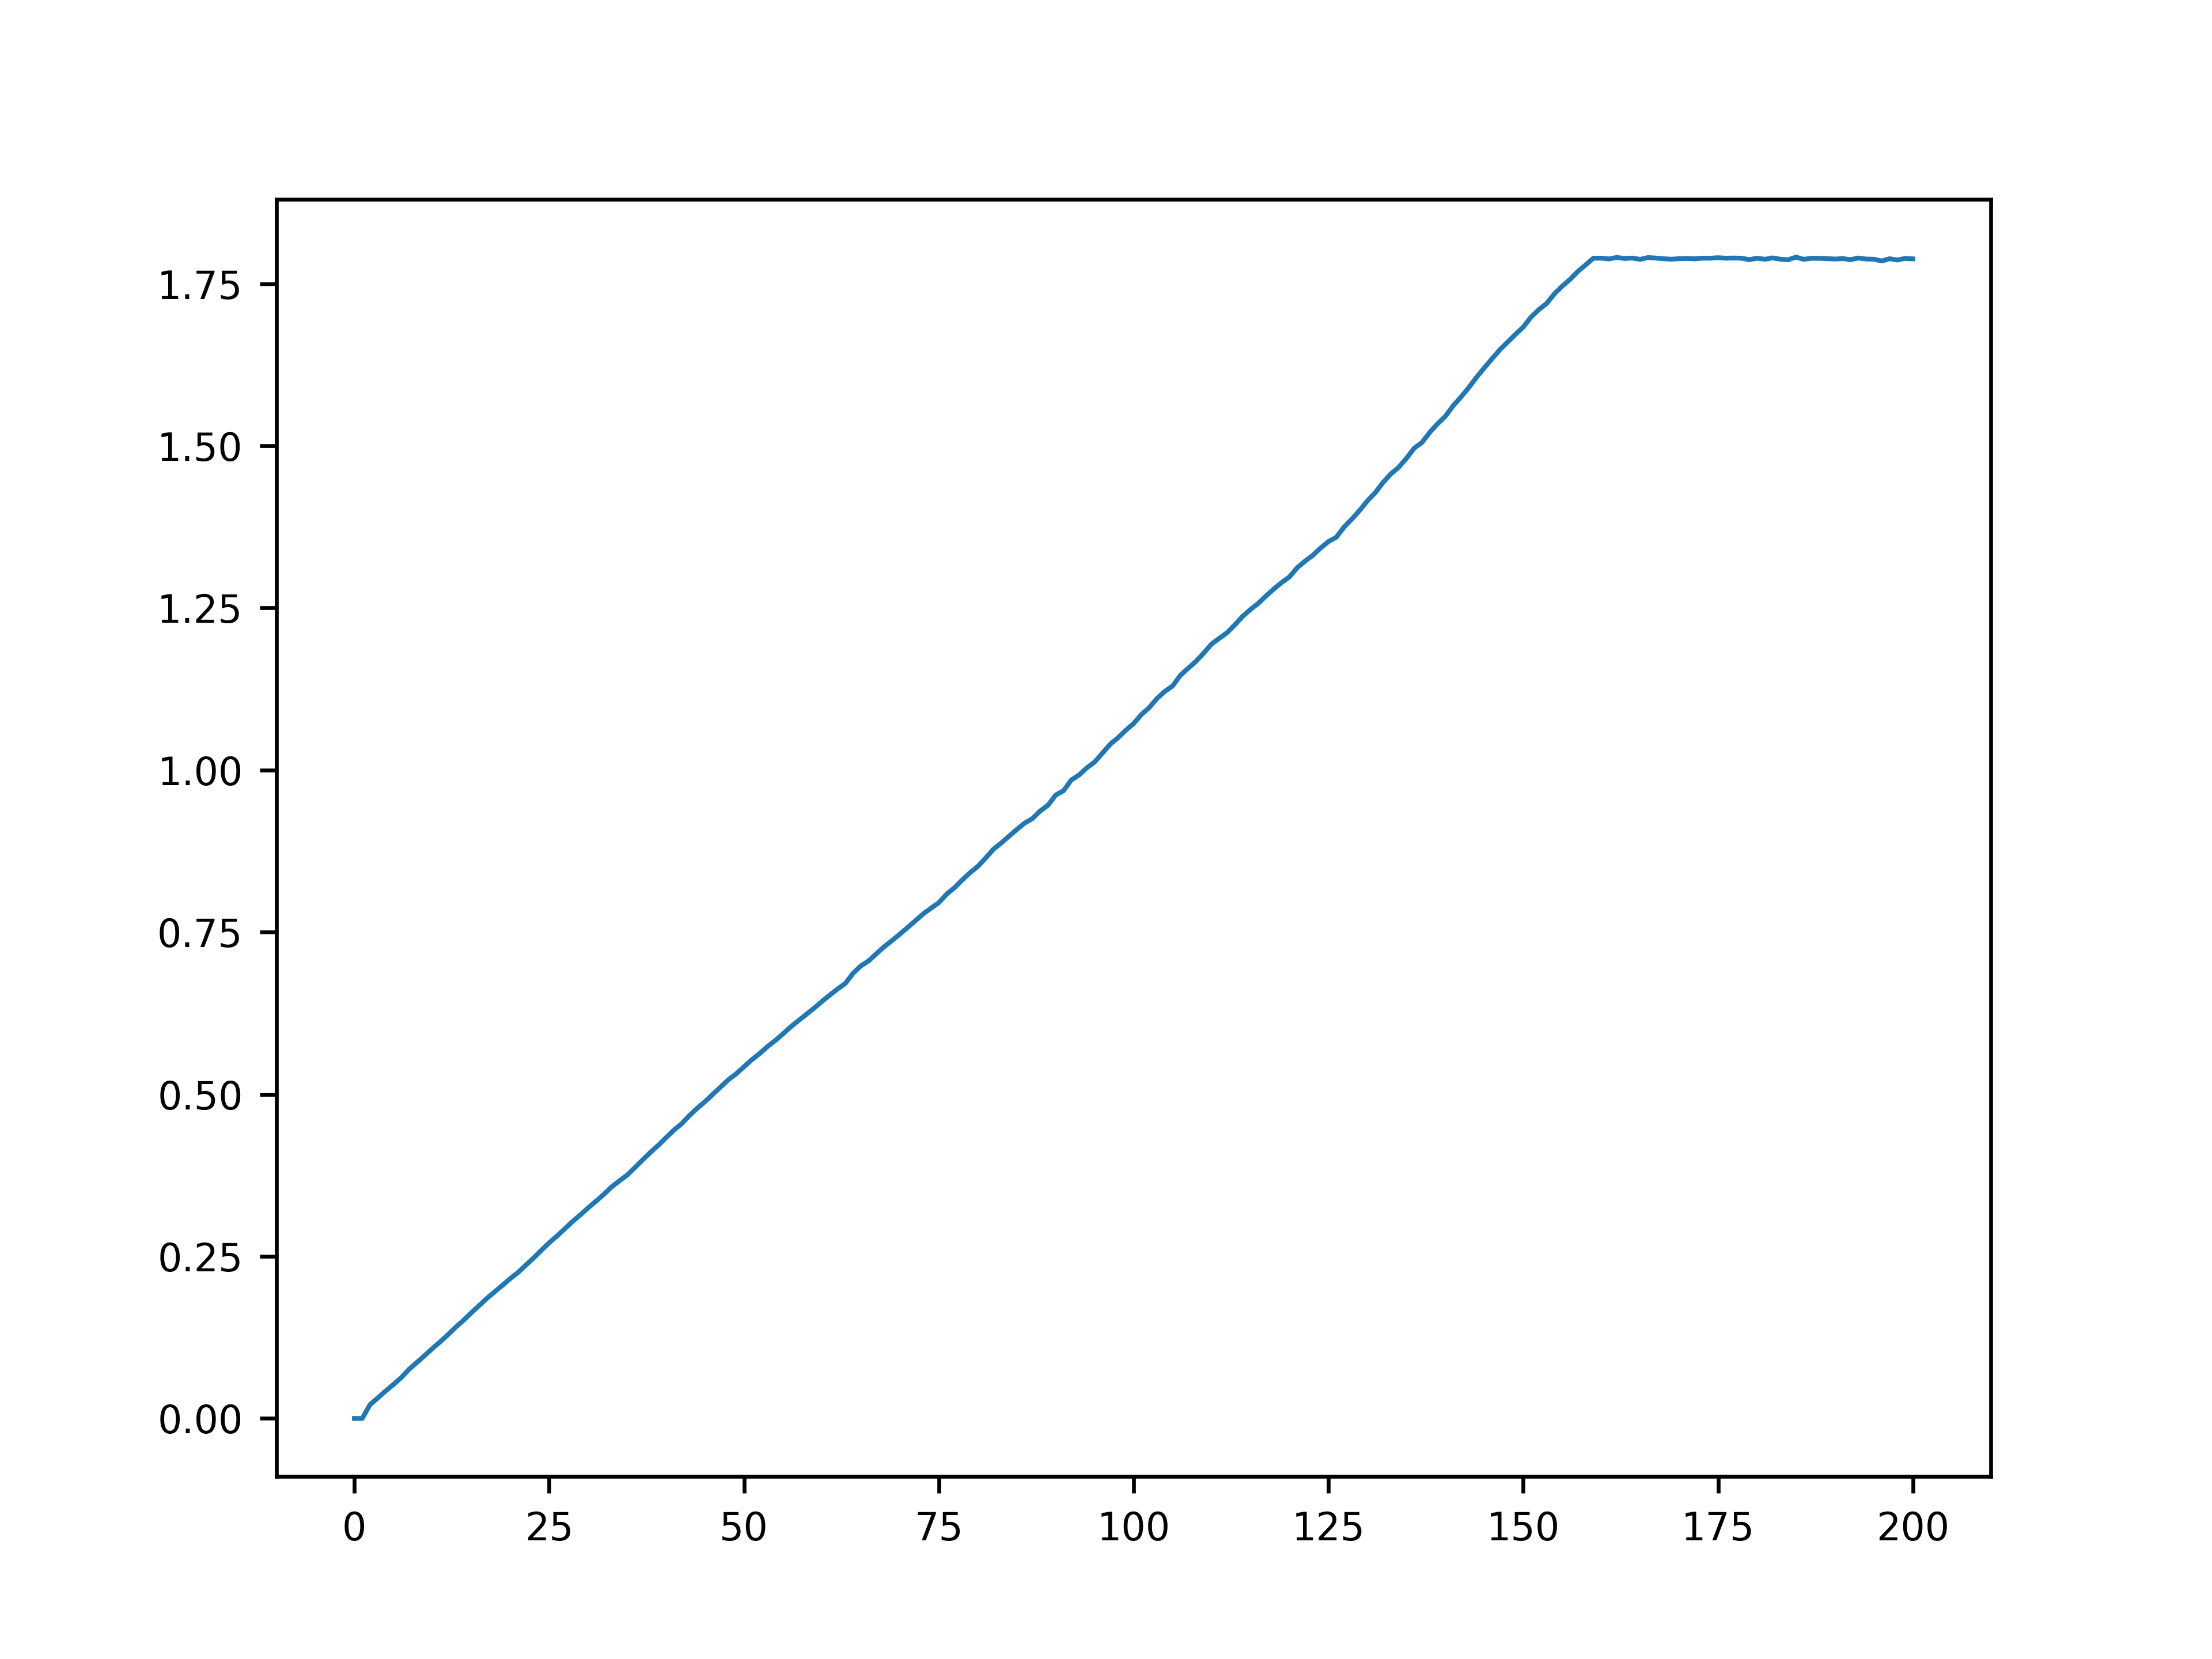

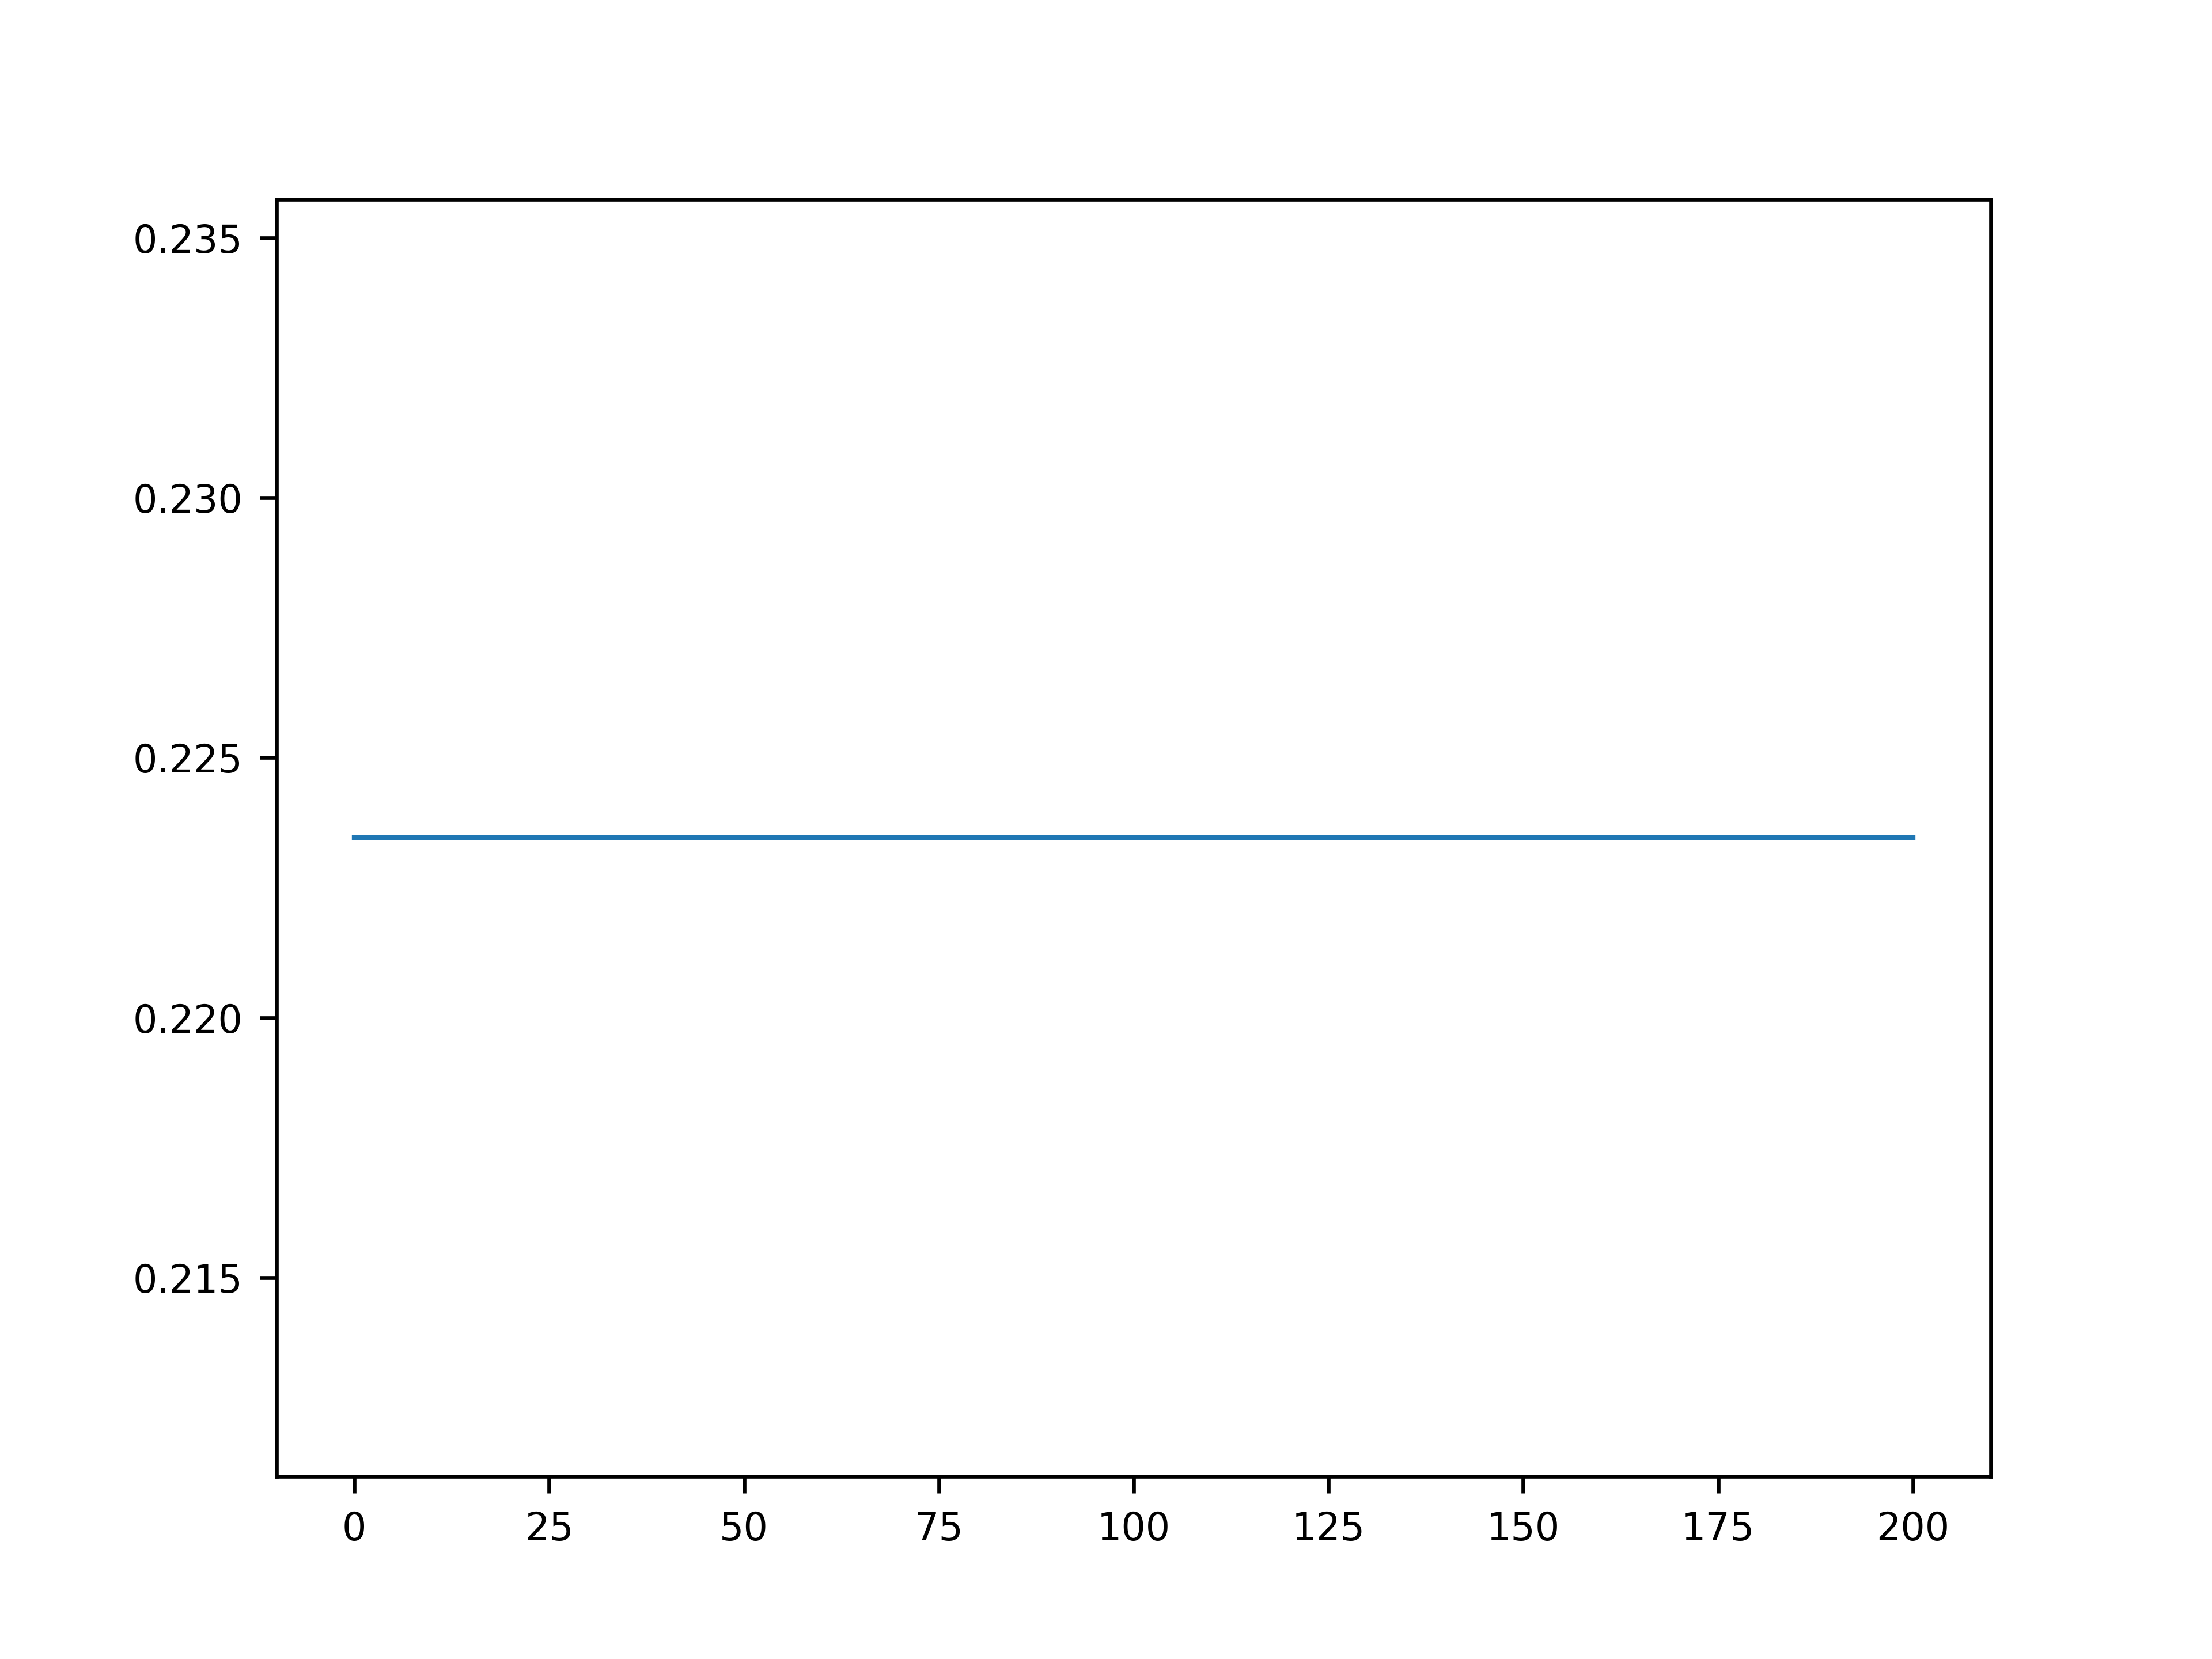

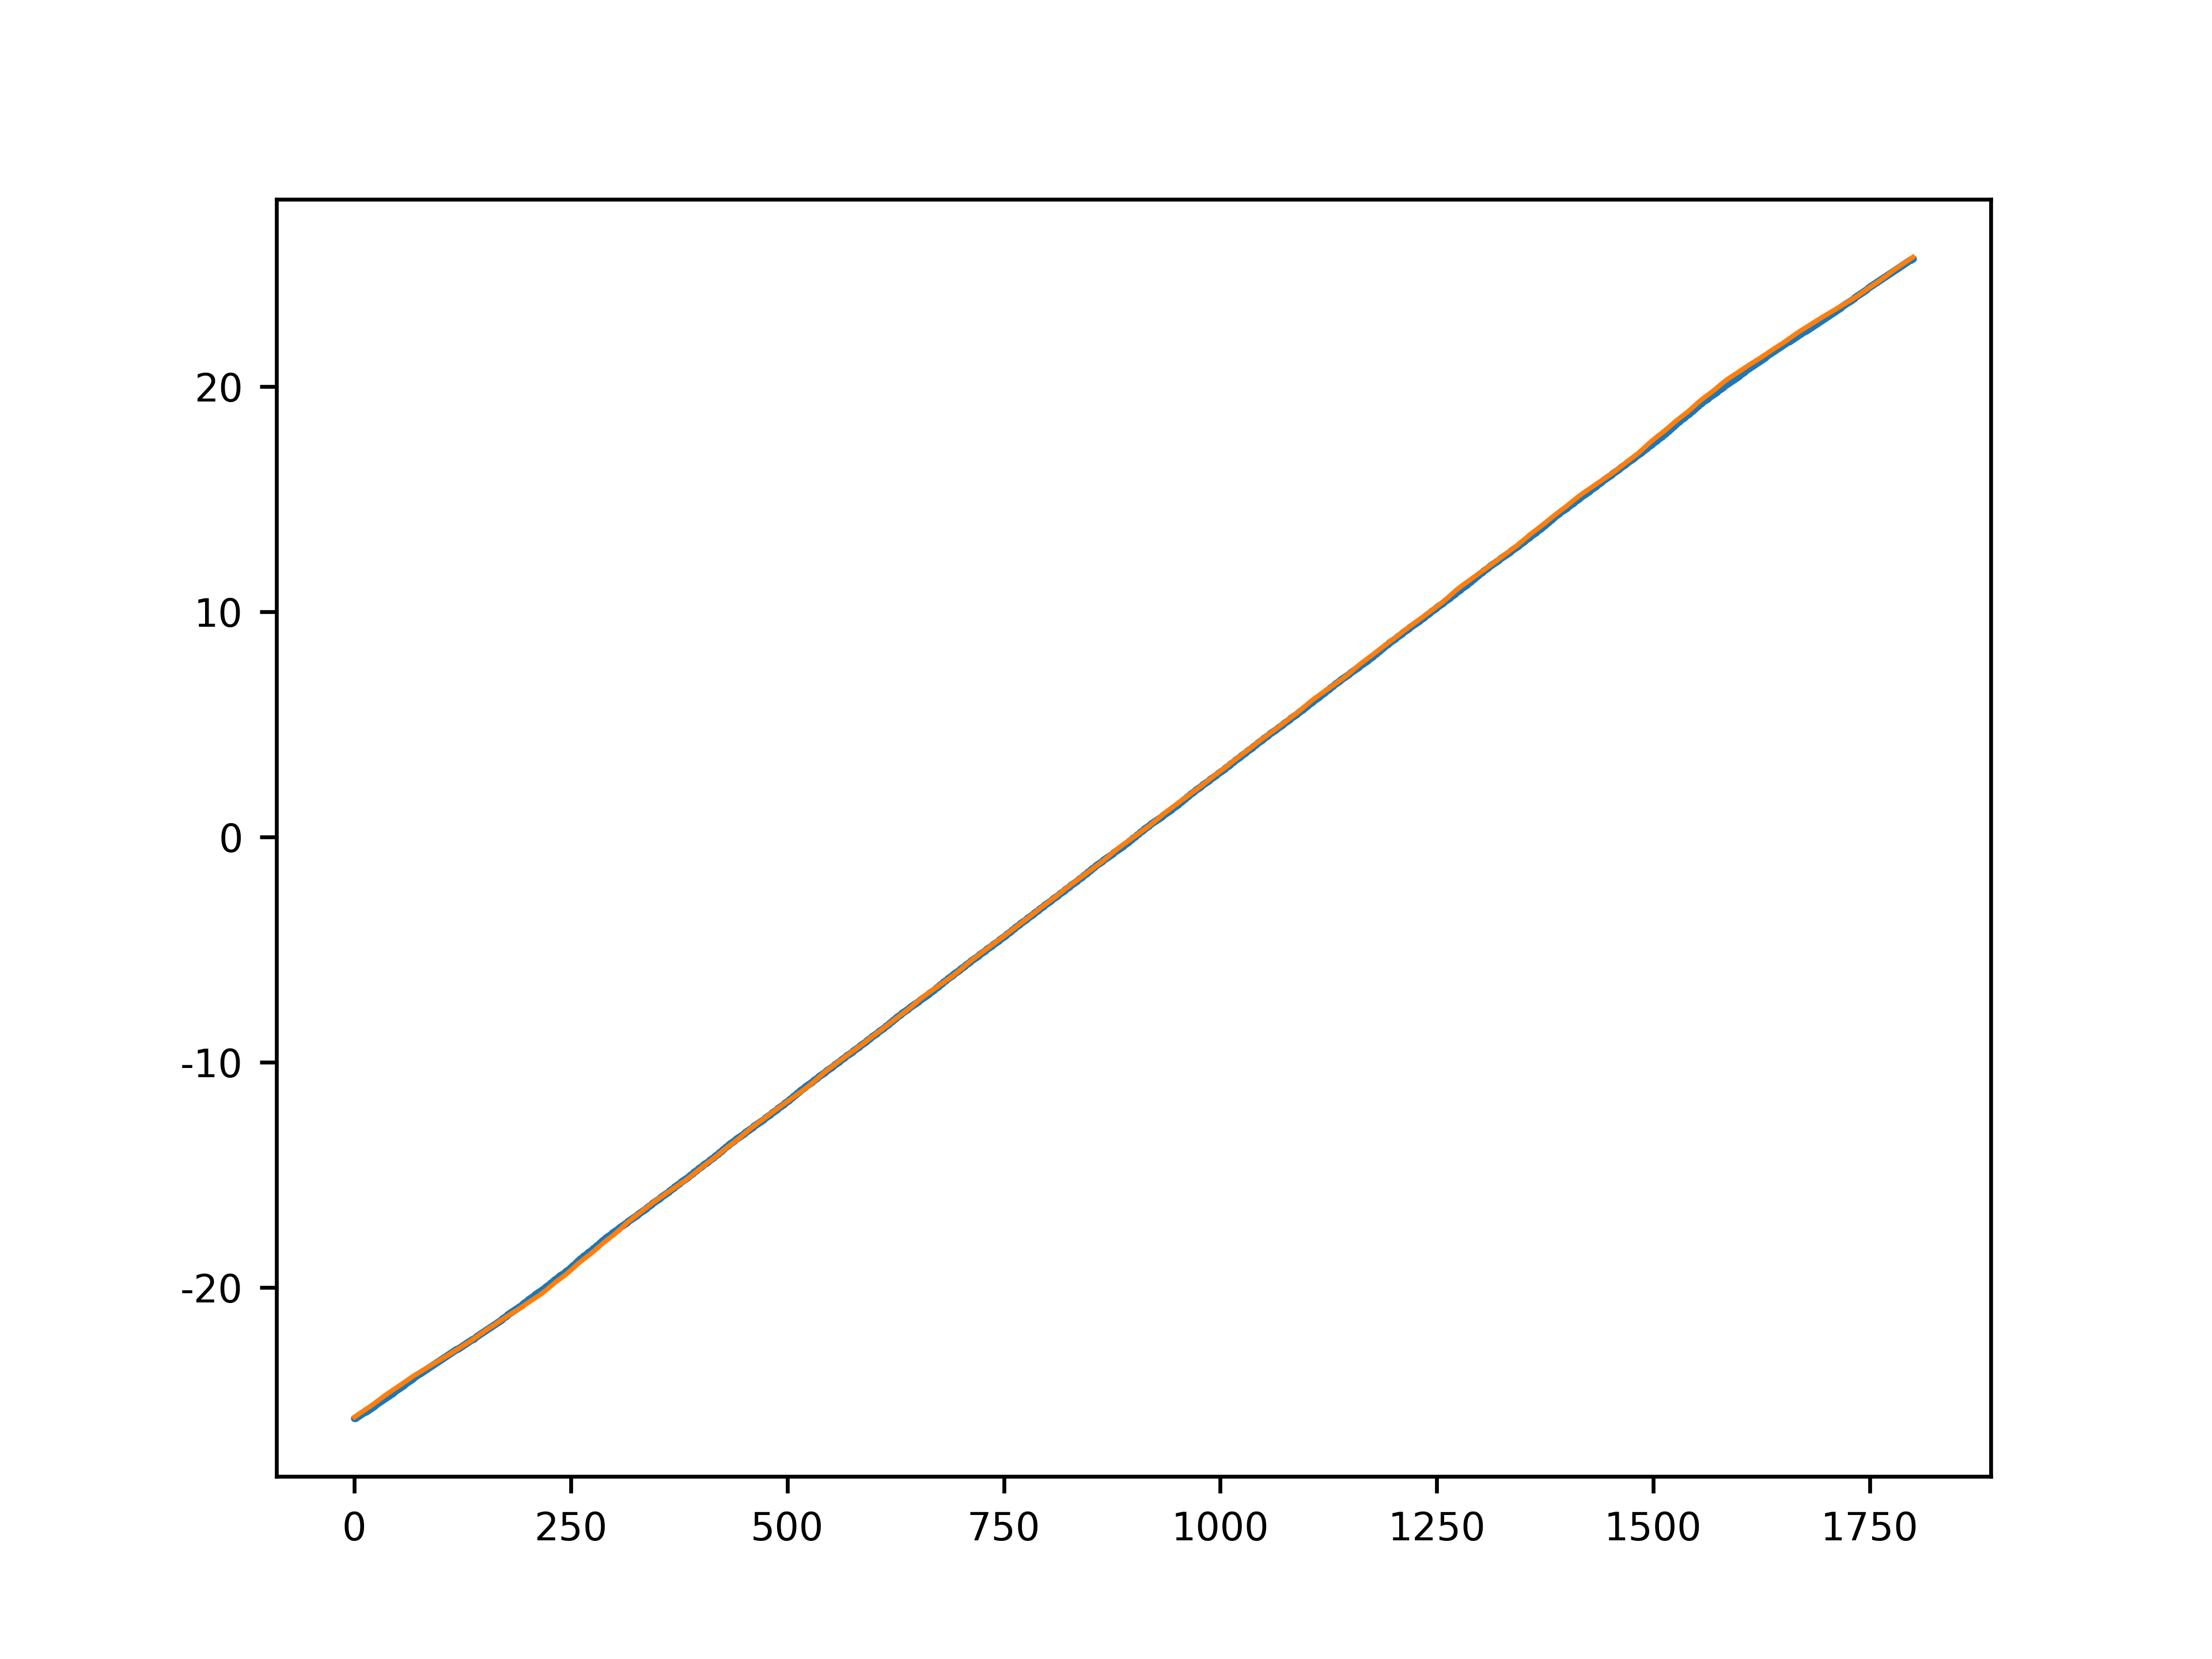

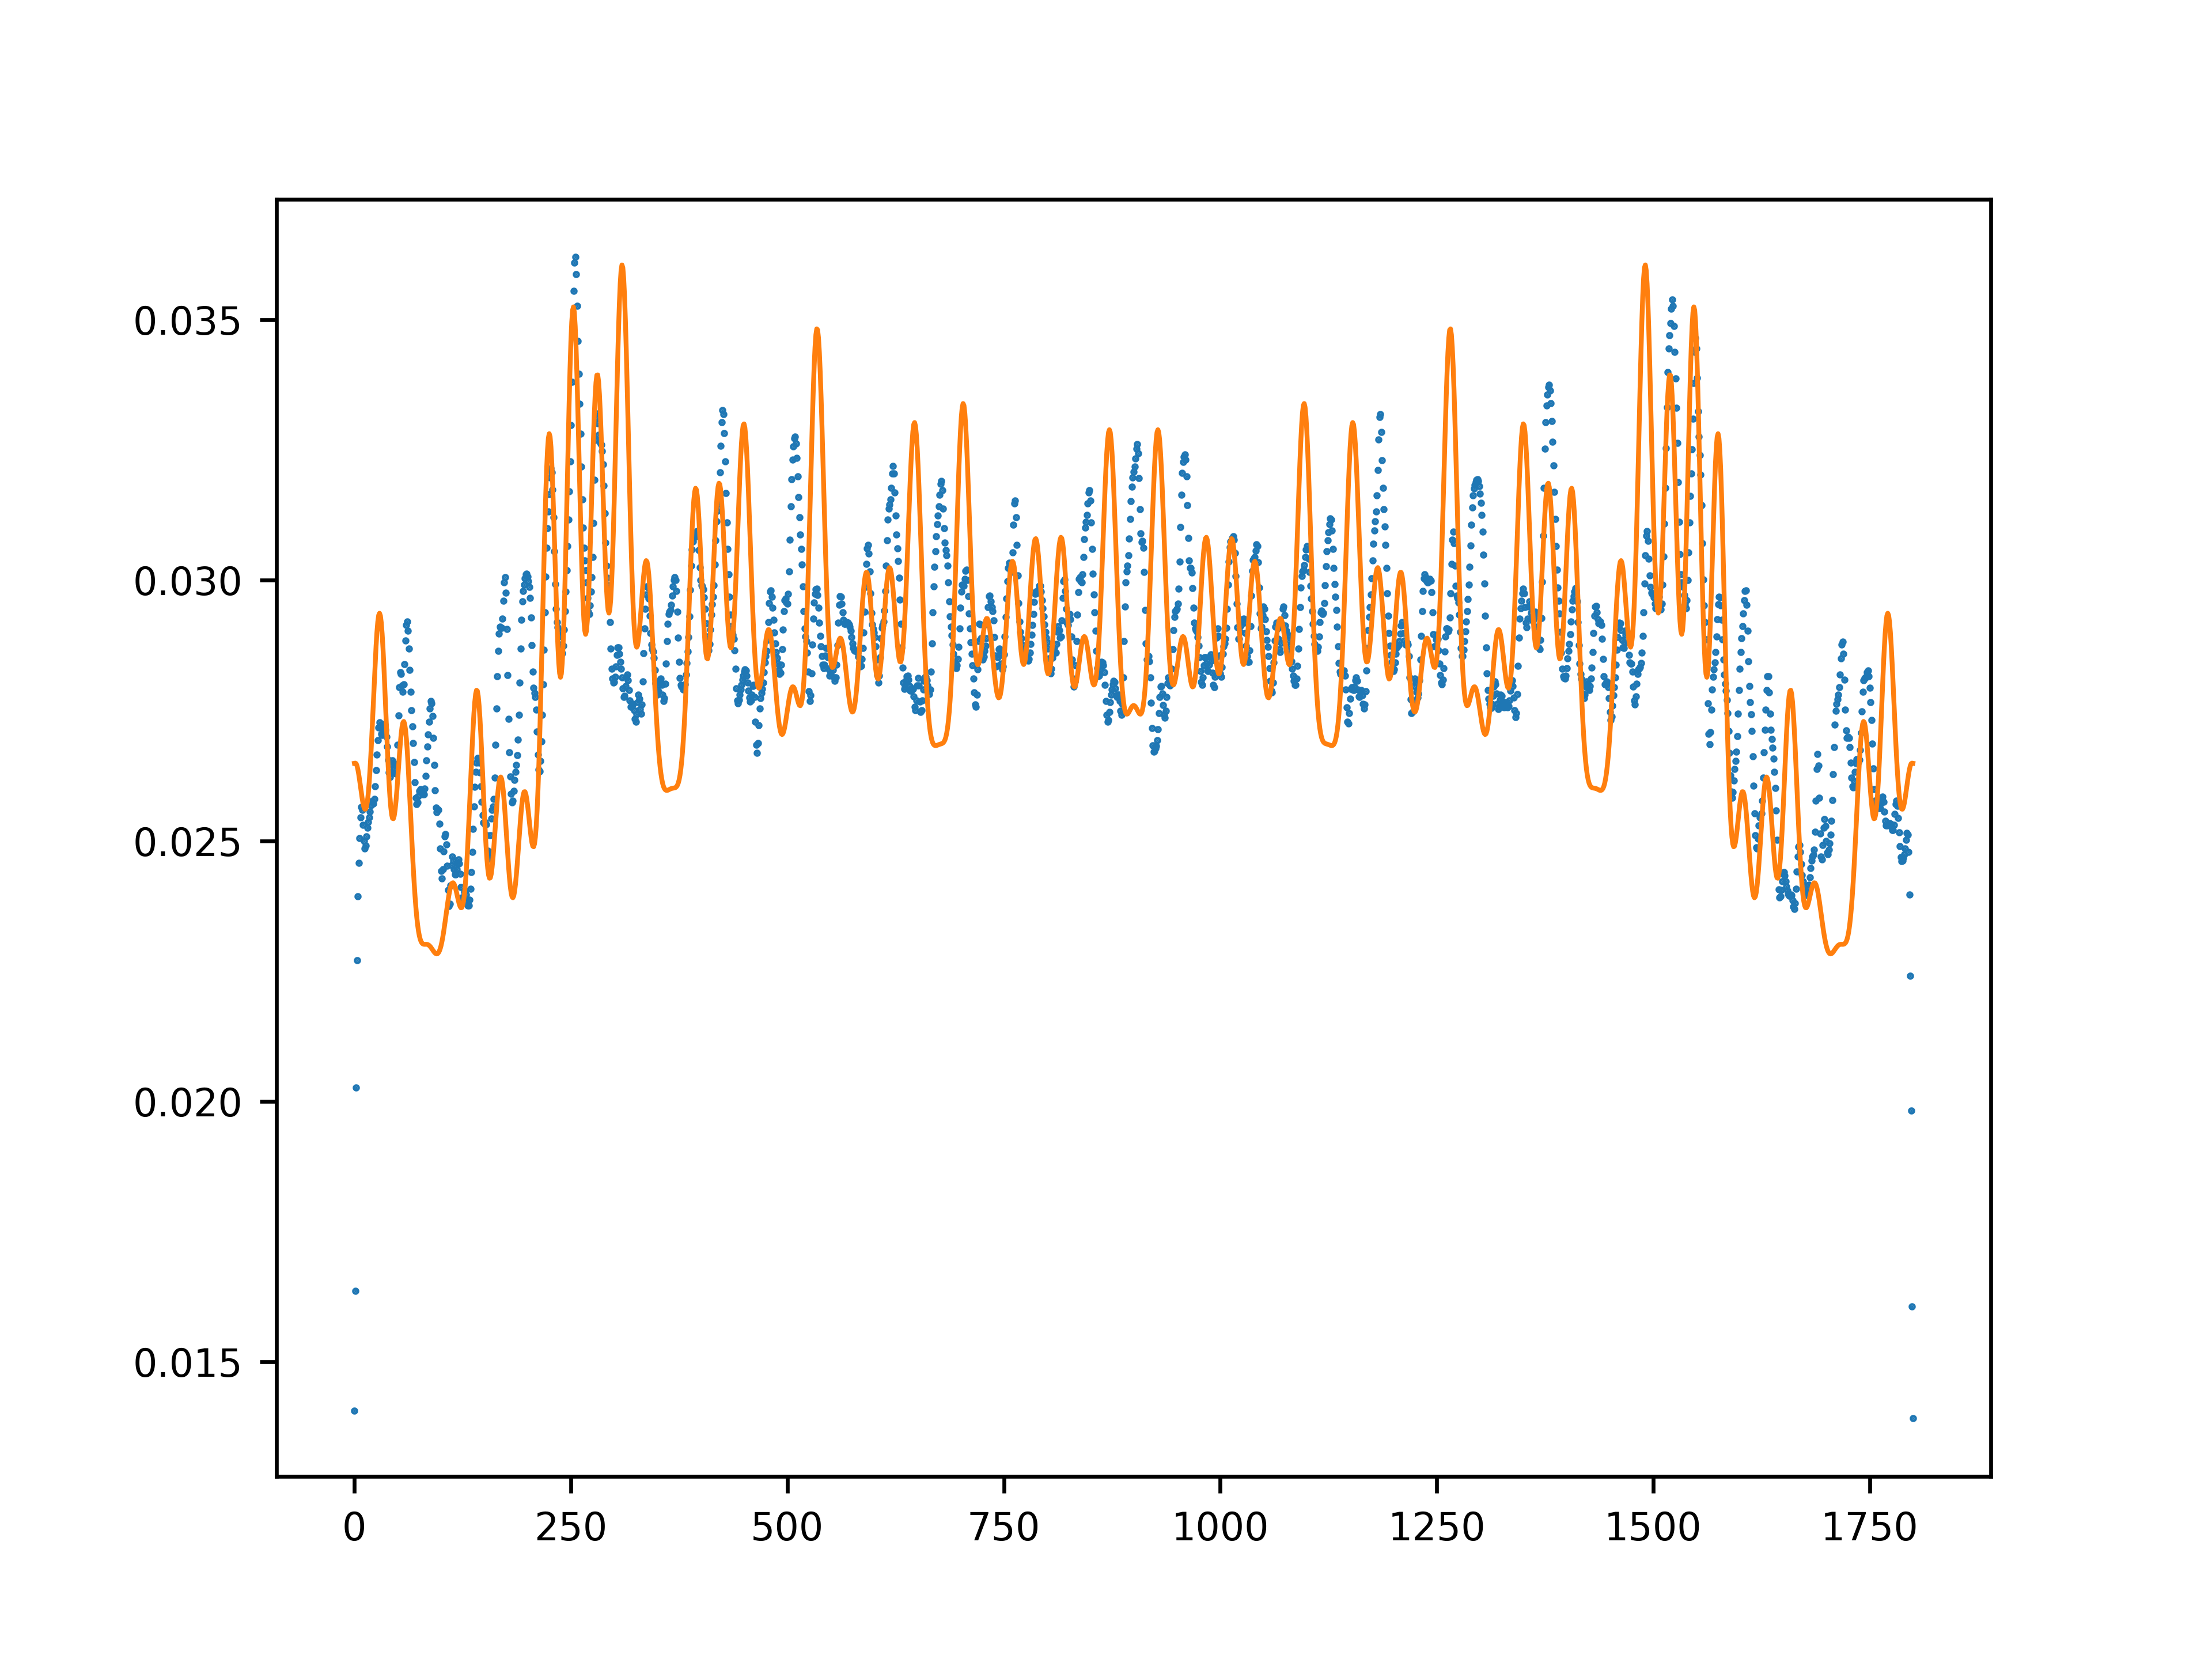

In [12]:
# test plots
i = 175
plt.figure(0)
plt.plot(fit_values["A_mV"])
plt.figure(1)
plt.plot(fit_values["T_K"])
plt.figure(2)
plt.plot(Iexp_nA[i, :], ".")
plt.plot(Ifit_nA[i, :])
plt.figure(3)
plt.plot(np.gradient(Iexp_nA[i, :]), ".")
plt.plot(np.gradient(Ifit_nA[i, :]))

In [13]:
# # fit_data 1
# # fit start values
# GN_G0: float = 0.18877592218372993
# Delta_meV: float = 0.19345000789195935
# gamma_meV: float = 0.005066874981090785

# # Initial values, bounds, and fixed state.
# settings = {
#     "GN_G0": (GN_G0, 0.1, 0.3, True),
#     "T_K": (0.2, 0.0, 1.2, False),
#     "Delta_meV": (Delta_meV, 0.180, 0.210, True),
#     "gamma_meV": (gamma_meV, 1e-9, 25e-3, True),
#     "A_mV": (0.0, 0.0, 4.0, False),
#     "nu_GHz": (nu_GHz, 1.0, 20.0, True),
# }
# from dataclasses import replace

# from superconductivity.optimizers import fit_model
# from superconductivity.optimizers.bcs import get_model_spec

# model = "pat_conv_jax"
# spec = get_model_spec(model)

# parameters = [
#     replace(
#         parameter,
#         guess=settings[parameter.name][0],
#         lower=settings[parameter.name][1],
#         upper=settings[parameter.name][2],
#         fixed=settings[parameter.name][3],
#     )
#     for parameter in spec.parameters
# ]

# n_curves = Iexp_nA.shape[0]

# I_fit_nA = np.full_like(Iexp_nA, np.nan, dtype=float)
# fit_values = {parameter.name: np.full(n_curves, np.nan) for parameter in parameters}
# fit_errors = {parameter.name: np.full(n_curves, np.nan) for parameter in parameters}
# solutions = []

# for index, current_nA in enumerate(tqdm(Iexp_nA)):
#     try:
#         solution = fit_model(
#             Vbias_mV,
#             current_nA,
#             model=model,
#             parameters=parameters,
#             maxfev=2_000,
#         )
#     except (RuntimeError, ValueError) as error:
#         print(f"Curve {index} failed: {error}")
#         solutions.append(None)
#         continue

#     solutions.append(solution)
#     I_fit_nA[index] = solution["I_fit_nA"]

#     for parameter in solution["params"]:
#         fit_values[parameter.name][index] = parameter.value
#         fit_errors[parameter.name][index] = parameter.error

#     # Warm-start the next curve while retaining bounds/fixed state.
#     parameters = [
#         replace(parameter, guess=parameter.value) for parameter in solution["params"]
#     ]

# output = "amp_18.3GHz/fit_data.npz"

# np.savez_compressed(
#     output,
#     I_fit_nA=I_fit_nA,
#     **{f"value_{name}": data for name, data in fit_values.items()},
#     **{f"error_{name}": data for name, data in fit_errors.items()},
# )

In [14]:
# load fit
data = np.load("amp_13.6GHz/fit_data2.npz")

try:
    Ifit_nA = data["I_fit_nA"]
except:
    Ifit_nA = data["Ifit_nA"]

fit_values = {
    key.removeprefix("value_"): data[key]
    for key in data.files
    if key.startswith("value_")
}

fit_errors = {
    key.removeprefix("error_"): data[key]
    for key in data.files
    if key.startswith("error_")
}

In [15]:
# binning
from superconductivity.utilities.functions.upsampling import upsample

Acal = np.linspace(0, 25, 101)
Acal_mV = Acal * (nu_GHz * sc.h_pVs)

Afit_mV = fit_values["A_mV"]
Afit = Afit_mV / (nu_GHz * sc.h_pVs)

Afitup = upsample(Afit, N_up=100)
Aoutup_mV = upsample(Aout_mV, N_up=100)
Iexpup_nA = upsample(Iexp_nA, N_up=100, axis=0)
dGexpup_G0 = upsample(dGexp_G0, N_up=100, axis=0)
dRexpup_R0 = upsample(dRexp_R0, N_up=100, axis=0)

valid = np.isfinite(Afitup)

Aoutcal_mV = sc.bin(
    z=Aoutup_mV[valid],
    x=Afitup[valid],
    xbins=Acal,
    axis=0,
)
Ical_nA = sc.bin(
    z=Iexpup_nA[valid, :],
    x=Afitup[valid],
    xbins=Acal,
    axis=0,
)
dGcal_G0 = sc.bin(
    z=dGexpup_G0[valid, :],
    x=Afitup[valid],
    xbins=Acal,
    axis=0,
)
dRcal_R0 = sc.bin(
    z=dRexpup_R0[valid, :],
    x=Afitup[valid],
    xbins=Acal,
    axis=0,
)

In [16]:
# saving calibrated data

Vbias = Vbias_mV / Delta_meV
Ibias = Ibias_nA / (GN_G0 * sc.G0_muS * Delta_meV)
Abias = Acal

Iexp = Ical_nA / (GN_G0 * sc.G0_muS * Delta_meV)
dGexp = dGcal_G0 / (GN_G0)
dRexp = dRcal_R0 * (GN_G0)

np.savez_compressed(
    "amp_13.6GHz/cal.npz",
    Vbias=Vbias,
    Ibias=Ibias,
    Abias=Abias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    nu_GHz=nu_GHz,
    GN_G0=GN_G0,
    Delta_meV=Delta_meV,
)

In [17]:
# saving fit data
Afit_K = fit_values["A_mV"]
uAfit_mV = fit_errors["A_mV"]
Tfit_K = fit_values["T_K"]
uTfit_K = fit_errors["T_K"]
np.savez_compressed(
    "amp_13.6GHz/fit.npz",
    Aout_mV=Aout_mV,
    Afit_mV=Afit_mV,
    uAfit_mV=uAfit_mV,
    Tfit_K=Tfit_K,
    uTfit_K=uTfit_K,
    nu_GHz=nu_GHz,
    GN_G0=GN_G0,
    Delta_meV=Delta_meV,
)